# Preprocessing Of Bot-IoT Dataset

**Purpose of this cell**
This cell imports all required libraries for the notebook:

* **Data handling**: `pandas`, `numpy`, `os`, `Path`
* **Deep learning**: `torch`, `torch.nn`, `Dataset`, `DataLoader`
* **Preprocessing & splitting**: `StandardScaler`, `LabelEncoder`, `train_test_split`
* **Evaluation metrics**: accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, classification report
* **Visualization**: `matplotlib`, `seaborn`
* **Utilities**: warning suppression for cleaner outputs

This sets up the full environment for data preprocessing, model training, and evaluation.



In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


This cell defines utility functions to load, explore, and manage the BoT-IoT dataset:

load_bot_iot_dataset: loads one or multiple CSV files, concatenates them into a single DataFrame, and keeps individual parts for reference

explore_dataset: performs basic dataset exploration (shape, columns, types, missing values, samples)

save_combined_dataset: saves the merged dataset to a CSV file

main: example workflow demonstrating how to load, explore, and optionally save the dataset

In [2]:
def load_bot_iot_dataset(base_path='./', files=None):
    """
    Load BoT-IoT dataset from multiple reduced CSV files.
    
    Parameters:
    -----------
    base_path : str
        Path to directory containing the CSV files
    files : list
        List of filenames to load. If None, loads the default 4 files.
        
    Returns:
    --------
    combined_df : pandas.DataFrame
        Combined dataset
    individual_dfs : dict
        Dictionary containing individual DataFrames
    """
    
    # Default files if none specified
    if files is None:
        files = [
            'C:/Users/vw/OneDrive/Bureau/transformer/TransformersFL/final_dataset.csv',
        ]
    
    individual_dfs = {}
    combined_df = None
    
    print(f"Loading BoT-IoT dataset from {len(files)} files...")
    
    for i, file_name in enumerate(files, 1):
        file_path = os.path.join(base_path, file_name)
        
        try:
            print(f"  Loading file {i}/{len(files)}: {file_name}")
            
            # Load CSV file
            df = pd.read_csv(file_path)
            
            # Store individual dataframe
            individual_dfs[f'part_{i}'] = df
            
            # Combine with previous data
            if combined_df is None:
                combined_df = df
            else:
                combined_df = pd.concat([combined_df, df], ignore_index=True)
                
            print(f"    ✓ Loaded {len(df)} rows, {len(df.columns)} columns")
            
        except FileNotFoundError:
            print(f"    ✗ File not found: {file_path}")
        except Exception as e:
            print(f"    ✗ Error loading {file_name}: {str(e)}")
    
    if combined_df is not None:
        print(f"\nDataset Summary:")
        print(f"Total rows: {len(combined_df):,}")
        print(f"Total columns: {len(combined_df.columns)}")
        print(f"Columns: {list(combined_df.columns)}")
        
    
    return combined_df, individual_dfs

def explore_dataset(df):
    """
    Basic exploration of the BoT-IoT dataset.
    """
    print("\n" + "="*50)
    print("DATASET EXPLORATION")
    print("="*50)
    
    print(f"\nShape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")
    
    print(f"\nData Types:")
    print(df.dtypes)
    
    print(f"\nMissing Values:")
    missing = df.isnull().sum()
    print(missing[missing > 0])
    
    print(f"\nFirst 5 rows:")
    print(df.head())
    
    # Check for categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        print(f"\nCategorical columns: {categorical_cols.tolist()}")
        for col in categorical_cols[:3]:  # Show first 3 categorical columns
            print(f"\nUnique values in '{col}': {df[col].nunique()}")
            print(df[col].value_counts().head())

def save_combined_dataset(df, output_path='combined_bot_iot.csv'):
    """
    Save the combined dataset to a single CSV file.
    """
    df.to_csv(output_path, index=False)
    print(f"\nCombined dataset saved to: {output_path}")
    print(f"Size: {os.path.getsize(output_path)/1024/1024:.2f} MB")

def main():
    # Example usage
    data_path = ''  # Update this with your actual path
    
    # Load all files
    combined_df, individual_dfs = load_bot_iot_dataset(data_path)
    
    if combined_df is not None:
        # Explore the dataset
        explore_dataset(combined_df)
        
        # Save combined dataset (optional)
        # save_combined_dataset(combined_df, 'bot_iot_combined.csv')
        
        # Example: Access individual parts
        print(f"\nLoaded {len(individual_dfs)} individual files")
        for key, df_part in individual_dfs.items():
            print(f"{key}: {len(df_part)} rows")
        
        return combined_df, individual_dfs
    
    return None, None


This cell executes the data-loading pipeline by calling main(), returning:

combined_data: the full merged BoT-IoT dataset

individual_data: a dictionary containing each loaded dataset segment

This initializes the dataset for further preprocessing and analysis.

In [3]:
combined_data, individual_data = main()

Loading BoT-IoT dataset from 1 files...
  Loading file 1/1: C:/Users/vw/OneDrive/Bureau/transformer/TransformersFL/final_dataset.csv
    ✓ Loaded 1354342 rows, 53 columns

Dataset Summary:
Total rows: 1,354,342
Total columns: 53
Columns: ['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'smac', 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'attack', 'category', 'subcategory ', 'flgs_number', 'proto_number', 'state_number', 'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP', 'TnP_PerProto', 'TnP_Per_Dport', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP', 'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport', 'Pkts_P_State_P_Protocol_P_DestIP', 'Pkts_P_State_P_Protocol_P_SrcIP', 'subcategory']

DATASET EXPLORATION

Shape: (1354342, 53)

Columns: ['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 's

**Purpose of this cell**
This cell defines the **global configuration** and the **data preprocessing pipeline**:

* `Config`: centralizes all experiment settings (target type, data split, model architecture, training hyperparameters, and device selection)
* `DataPreprocessor`: implements a clean preprocessing workflow:

  * selects relevant features
  * encodes the target labels
  * handles categorical and numerical features
  * fills missing values
  * normalizes numerical data

This prepares the dataset in a format suitable for model training.


In [4]:
# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Single configuration for everything"""
    
    # Target (change this for binary vs multi-class)
    TARGET = 'category'  # 'attack' for binary, 'category' for 5-class, 'subcategory' for 8-class
    N_CLASSES = 5  # 2 for binary, 5 for category, 8 for subcategory
    
    # Data split
    TEST_SIZE = 0.2
    VAL_SIZE = 0.1
    RANDOM_STATE = 42
    
    # Model architecture
    D_MODEL = 128
    N_HEADS = 8
    N_LAYERS = 6
    D_FFN = 512
    DROPOUT = 0.1
    
    # Training
    BATCH_SIZE = 2048
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    EPOCHS = 10
    PATIENCE = 10
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================================
# DATA PREPROCESSING
# ============================================================================

class DataPreprocessor:
    """Clean preprocessing pipeline"""
    
    def __init__(self, config):
        self.config = config
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.cat_encoders = {}
        
    def preprocess(self, df):
        """Preprocess data with proper cleaning"""
        print("\n" + "="*60)
        print("PREPROCESSING")
        print("="*60)
        
        # Keep only these columns
        columns_to_keep = [
            'pkSeqID', 'stime', 'flgs', 'flgs_number', 'proto', 'proto_number',
            'saddr', 'sport', 'daddr', 'dport', 'pkts', 'bytes', 'state',
            'state_number', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'sum', 'min',
            'max', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate',
            'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP', 'TnP_PerProto',
            'TnP_Per_Dport', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP',
            'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'AR_P_Proto_P_Sport',
            'AR_P_Proto_P_Dport', 'Pkts_P_State_P_Protocol_P_DestIP',
            'Pkts_P_State_P_Protocol_P_SrcIP', 'attack', 'category', 'subcategory'
        ]
        
        df = df[columns_to_keep].copy()
        
        # Clean column names
        df.columns = df.columns.str.strip()
        df = df.loc[:, ~df.columns.duplicated()]
        
        # Encode target
        y = self.label_encoder.fit_transform(df[self.config.TARGET])
        print(f"\nTarget: {self.config.TARGET}")
        for i, cls in enumerate(self.label_encoder.classes_):
            print(f"  Class {i} ({cls}): {(y == i).sum():,}")
        
        # Drop high-cardinality and target columns
        drop_cols = ['pkSeqID', 'stime', 'ltime', 'saddr', 'sport', 'daddr', 'dport',
                     'attack', 'category', 'subcategory']
        X = df.drop(columns=[c for c in drop_cols if c in df.columns])
        
        # Fill NaN with 0
        X = X.fillna(0)
        
        # Categorical vs numerical
        cat_cols = ['flgs', 'proto', 'state']
        cat_cols = [c for c in cat_cols if c in X.columns]
        num_cols = [c for c in X.columns if c not in cat_cols]
        
        print(f"\nFeatures: {len(X.columns)}")
        print(f"  Categorical: {len(cat_cols)}")
        print(f"  Numerical: {len(num_cols)}")
        
        # Encode categoricals
        for col in cat_cols:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            self.cat_encoders[col] = le
        
        # Convert to numpy
        X_array = X.values.astype(np.float32)
        
        # Normalize ONLY numerical columns
        num_idx = [X.columns.tolist().index(c) for c in num_cols]
        X_array[:, num_idx] = self.scaler.fit_transform(X_array[:, num_idx])
        
        print(f"\nPreprocessed shape: {X_array.shape}")
        print(f"Feature range: [{X_array.min():.2f}, {X_array.max():.2f}]")
        print("="*60)
        
        return X_array, y

# TabularDataset

A lightweight PyTorch `Dataset` wrapper that converts preprocessed numpy arrays into tensors ready for model training.

| Argument | Shape | Description |
|----------|-------|-------------|
| `X` | `(n_samples, 36)` | Scaled & encoded feature matrix |
| `y` | `(n_samples,)` | Class labels: 0=DDoS, 1=DoS, 2=Normal, 3=Recon, 4=Theft |

This class is instantiated three times for **train**, **validation**, and **test** splits  and passed to a `DataLoader` (batch size `2048`) that handles shuffling and batching during the training loop.


**Dataset** → defines *what* one data sample looks like

**DataLoader** → defines *how* data is delivered to the model (batching, shuffling, speed)

In [ ]:
# ============================================================================
# DATASET
# ============================================================================

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Transformers

## What is this class doing, in simple words?

Imagine you have a table of data (like an Excel sheet). Each row is a network traffic sample with 36 columns (features). The goal is to teach the model to look at those 36 values and say *"this is a DDoS attack"* or *"this is normal traffic"*.

The **FT-Transformer** does this by treating each column (feature) as if it were a **word in a sentence**, then using the Transformer originally invented for language to find relationships between those "words".


## The Building Blocks

### 1. Feature Embeddings
```python
self.feature_embeddings = nn.ModuleList([
    nn.Linear(1, d_model) for _ in range(n_features)
])
```

**The problem:** Each feature is just one number (`packet_size = 0.73`). But the Transformer needs richer, more expressive representations to work with not just a single number.

**The solution:** Each feature gets its own **personal translator**, a small linear layer that takes that 1 number and expands it into a vector of 128 numbers (`d_model=128`).

Think of it like this: instead of describing a person with just their age (`25`), you now describe them with 128 characteristics derived from that age. Much richer.

So after this step, instead of a row of 36 numbers, we have **36 vectors of size 128**.

### 2. CLS Token
```python
self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
```

This is a **special learnable vector** prepended to the sequence, borrowed from BERT (a famous language model).

Think of it as a **"summary seat"** at the beginning of a classroom. All the other students (features) share information with each other, and this special seat absorbs everything and produces the final answer.

It starts as random noise, but during training it **learns** to collect the most useful information from all features.

After adding it, our sequence goes from 36 vectors → **37 vectors** (CLS + 36 features).


### 3. Transformer Encoder
```python
encoder_layer = nn.TransformerEncoderLayer(
    d_model=128,
    nhead=8,
    dim_feedforward=512,
    dropout=0.1,
    batch_first=True
)
self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6)
```

This is the **heart of the model**. Here's what happens inside:

**Multi-Head Attention (`nhead=8`):**
Every feature looks at every other feature and asks *"how relevant are you to me?"*. This is done 8 times in parallel (8 heads), each focusing on different kinds of relationships. For example, one head might learn that `packet_size` and `flow_duration` are strongly related, while another learns something else entirely.

**Feedforward Network (`dim_feedforward=512`):**
After attention, each vector passes through a small neural network that processes the gathered information independently.

**6 Layers (`num_layers=6`):**
This entire process repeats 6 times, each time refining the understanding. Early layers catch simple patterns, deeper layers catch complex ones.

**Dropout (`dropout=0.1`):**
During training, 10% of connections are randomly turned off. This forces the model not to rely too heavily on any single feature, making it more robust and preventing overfitting.


### 4. 🎯 Classification Head
```python
self.head = nn.Sequential(
    nn.LayerNorm(d_model),
    nn.ReLU(),
    nn.Dropout(dropout),
    nn.Linear(d_model, n_classes)
)
```

After the Transformer finishes, we only look at the **CLS token** (position 0) — it has absorbed information from all features.

Then:
- **LayerNorm** → stabilizes the values (keeps numbers in a healthy range)
- **ReLU** → introduces non-linearity (allows the model to learn complex patterns)
- **Dropout** → regularization again
- **Linear(128 → 5)** → final decision: maps the 128-dimensional CLS vector into **5 scores**, one per class

The class with the highest score wins → that's the prediction.

## The Forward Pass — Full Data Journey

```python
def forward(self, x):  # x shape: (2048, 36)
```

| Step | What happens | Shape |
|------|-------------|-------|
| Input | Batch of samples | `(2048, 36)` |
| Feature embedding | Each of 36 features → 128-dim vector | `(2048, 36, 128)` |
| Add CLS token | Prepend learnable summary token | `(2048, 37, 128)` |
| Transformer (×6) | Features attend to each other | `(2048, 37, 128)` |
| Take CLS output | Extract position 0 only | `(2048, 128)` |
| Classification head | Map to class scores | `(2048, 5)` |


## The Big Picture Analogy

> Imagine 36 students (features) sitting in a room. Each student whispers their information to all others (attention). They do this 6 rounds (layers). One special student — the CLS token — sits in the middle, listens to everyone, and at the end raises their hand to give the final answer: *"This is a DDoS attack."*


**Total parameters: 1,199,877** — printed automatically when the model is created. This is how many numbers the model learns during training to get that 98.4% accuracy.

In [ ]:
# ============================================================================
# MODEL
# ============================================================================

class FTTransformer(nn.Module):
    """FT-Transformer model"""
    
    def __init__(self, n_features, d_model, n_heads, n_layers, d_ffn, n_classes, dropout):
        super().__init__()
        
        # Feature embeddings
        self.feature_embeddings = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(n_features)
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        
        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ffn,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes)
        )
        
        print(f"\nModel: {sum(p.numel() for p in self.parameters()):,} parameters")
    
    def forward(self, x):
        batch_size = x.size(0)
        
        # Embed features
        embeddings = [self.feature_embeddings[i](x[:, i:i+1]) for i in range(x.size(1))]
        embeddings = torch.stack(embeddings, dim=1)
        
        # Add CLS token
        cls = self.cls_token.expand(batch_size, -1, -1)
        embeddings = torch.cat([cls, embeddings], dim=1)
        
        # Transformer
        embeddings = self.transformer(embeddings)
        
        # Classification
        return self.head(embeddings[:, 0])

# The `Trainer` Class

### What is this class doing, in simple words?

After building the model, you need something to actually **run the training process** — feeding data in, measuring mistakes, adjusting weights, and deciding when to stop. That's exactly what `Trainer` does. Think of it as the **coach** of the model: it runs practice sessions, tracks performance, saves the best version, and knows when to call it done.


## The Building Blocks

### 1. `__init__` — Setup
```python
self.history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [], 'val_auc': []}
self.best_f1 = 0
```
Initializes the model on the correct device (GPU/CPU) and creates a **history dictionary** to record metrics after each epoch — useful for plotting learning curves later. `best_f1` tracks the best validation score seen so far.


### 2. `train_epoch` — One Training Round

```python
def train_epoch(self, loader, optimizer, criterion):
    self.model.train()
```

This runs **one full pass** through the entire training set. Here's what happens for each batch:

```python
optimizer.zero_grad()   # Clear old gradients
out = self.model(X)     # Forward pass → get predictions
loss = criterion(out, y) # Measure how wrong we were
loss.backward()          # Backprop → compute gradients
optimizer.step()         # Update weights
```

**The learning loop in plain English:**
1. Show the model a batch of 2048 samples
2. It makes predictions
3. We measure the error (loss)
4. We trace back through the network to find which weights caused that error *(backward pass)*
5. We nudge those weights in the right direction *(optimizer step)*
6. Repeat for all batches

`self.model.train()` is important — it activates **Dropout**, which randomly disables neurons during training to prevent overfitting.


### 3. `validate` — Checking Performance Without Learning

```python
def validate(self, loader, criterion):
    self.model.eval()
    with torch.no_grad():
```

Similar to `train_epoch` but with two key differences:
- `model.eval()` → **disables Dropout** (we want consistent, deterministic predictions)
- `torch.no_grad()` → **no gradient computation** (we're not learning here, just measuring — saves memory and time)

**Metrics computed:**
| Metric | What it measures |
|--------|-----------------|
| `accuracy` | % of correct predictions overall |
| `precision` | Of all samples predicted as class X, how many truly were X? |
| `recall` | Of all true class X samples, how many did we catch? |
| `F1` | Harmonic mean of precision & recall — the main tracking metric here |
| `AUC` | How well the model separates classes (1.0 = perfect) |

```python
probs.append(F.softmax(out, dim=1))
```
`Softmax` converts raw model scores into **probabilities** that sum to 1 — needed for AUC calculation.

### 4. `fit` — The Full Training Loop

This is the main method that orchestrates everything. Let's break it down:

**Optimizer — AdamW:**
```python
optimizer = torch.optim.AdamW(lr=1e-4, weight_decay=1e-5)
```
AdamW is the algorithm that updates the model's weights after each batch. It's an improved version of the classic gradient descent — it adapts the learning rate for each parameter individually and adds **weight decay** to prevent weights from growing too large.

**Loss Function — CrossEntropyLoss with class weights:**
```python
criterion = nn.CrossEntropyLoss(weight=class_weights)
# weights: [0.77, 1.59, 28.38, 0.33, 170.66]
```
Because the dataset is heavily imbalanced (Theft has only 1,587 samples vs Reconnaissance's 823,632), we tell the loss function to **penalize mistakes on rare classes much more harshly**. Getting a Theft sample wrong costs 170× more than getting a Reconnaissance sample wrong.

**Scheduler — ReduceLROnPlateau:**
```python
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(mode='max', factor=0.5, patience=3)
```
If the validation F1 stops improving for 3 epochs, the learning rate is **cut in half**. Think of it as the coach telling the team *"our current approach isn't working, let's take smaller, more careful steps"*.

**Early Stopping:**
```python
if patience >= self.config.PATIENCE:  # PATIENCE=10
    print("Early stopping triggered!")
    break
```
If validation F1 doesn't improve for 10 consecutive epochs, training stops early. This prevents wasting compute time and overfitting to training data.

**Best Model Saving:**
```python
if val_f1 > self.best_f1:
    torch.save(self.model.state_dict(), 'best_model.pth')
```
Every time a new best F1 is achieved, the model weights are saved to disk. At the end of training, the best version is reloaded — not necessarily the last epoch.


### 5. `evaluate` — Final Test Set Report

```python
def evaluate(self, test_loader, class_names):
```

After training is done, this method runs the **final assessment on unseen test data**. It:
- Computes all metrics (accuracy, precision, recall, F1, AUC)
- Builds the **confusion matrix** — a table showing exactly which classes get confused with which
- Prints the full **classification report** per class

The confusion matrix is especially revealing for this dataset — it showed that Theft (only 317 test samples) had high recall but very low precision, meaning the model catches most Theft cases but also falsely flags many Reconnaissance samples as Theft.


## The Full Training Flow

```
fit() called
    │
    ├── for each epoch:
    │       ├── train_epoch()  → learn from training data
    │       ├── validate()     → check on validation data
    │       ├── scheduler.step() → maybe reduce learning rate
    │       ├── save if best F1
    │       └── early stop if no improvement for 10 epochs
    │
    └── load best model weights
    
evaluate() called → final report on test set
```

### Simple analogy

> The model is a **student**. Each epoch is a **study session** where they practice on training examples. After each session, they take a **mock exam** (validation). The scheduler is like saying *"you're not improving — slow down and study more carefully"*. Early stopping says *"you've peaked, no point continuing"*. And at the end, the student takes the **real exam** (test set) — using the version of themselves that performed best on the mock exams.

In [ ]:
# ============================================================================
# TRAINER
# ============================================================================

class Trainer:
    """Training pipeline"""
    
    def __init__(self, model, config):
        self.model = model.to(config.DEVICE)
        self.config = config
        self.device = config.DEVICE
        
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_f1': [], 'val_f1': [], 'val_auc': []
        }
        self.best_f1 = 0
    
    def train_epoch(self, loader, optimizer, criterion):
        self.model.train()
        losses, preds, labels = [], [], []
        
        for X, y in loader:
            X, y = X.to(self.device), y.to(self.device)
            
            optimizer.zero_grad()
            out = self.model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
            losses.append(loss.item())
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
        
        return np.mean(losses), f1_score(labels, preds, average='weighted')
    
    def validate(self, loader, criterion):
        self.model.eval()
        losses, preds, labels, probs = [], [], [], []
        
        with torch.no_grad():
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                out = self.model(X)
                
                losses.append(criterion(out, y).item())
                probs.append(F.softmax(out, dim=1).cpu().numpy())
                preds.extend(out.argmax(1).cpu().numpy())
                labels.extend(y.cpu().numpy())
        
        probs = np.vstack(probs)
        
        # Metrics
        acc = accuracy_score(labels, preds)
        prec = precision_score(labels, preds, average='weighted', zero_division=0)
        rec = recall_score(labels, preds, average='weighted', zero_division=0)
        f1 = f1_score(labels, preds, average='weighted', zero_division=0)
        
        try:
            auc = roc_auc_score(labels, probs, multi_class='ovr', average='weighted')
        except:
            auc = 0.0
        
        return np.mean(losses), acc, prec, rec, f1, auc
    
    def fit(self, train_loader, val_loader, class_weights=None):
        """Train the model"""
        print("\n" + "="*60)
        print("TRAINING")
        print("="*60)
        
        # Setup
        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=self.config.LEARNING_RATE,
            weight_decay=self.config.WEIGHT_DECAY
        )
        
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        if class_weights is not None:
            print(f"\nClass weights: {class_weights.cpu().numpy()}")
        
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3
        )
        
        print(f"Batch size: {self.config.BATCH_SIZE}")
        print(f"Learning rate: {self.config.LEARNING_RATE}")
        print(f"Epochs: {self.config.EPOCHS}")
        print(f"Device: {self.device}\n")
        
        patience = 0
        
        for epoch in range(self.config.EPOCHS):
            print(f"{'='*60}")
            print(f"Epoch {epoch+1}/{self.config.EPOCHS}")
            print(f"{'='*60}")
            
            # Train
            train_loss, train_f1 = self.train_epoch(train_loader, optimizer, criterion)
            
            # Validate
            val_loss, val_acc, val_prec, val_rec, val_f1, val_auc = self.validate(val_loader, criterion)
            
            # Store history
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_f1'].append(train_f1)
            self.history['val_f1'].append(val_f1)
            self.history['val_auc'].append(val_auc)
            
            # Print metrics
            print(f"\nTrain:")
            print(f"  Loss: {train_loss:.4f}")
            print(f"  F1:   {train_f1:.4f}")
            
            print(f"\nValidation:")
            print(f"  Loss:      {val_loss:.4f}")
            print(f"  Accuracy:  {val_acc:.4f}")
            print(f"  Precision: {val_prec:.4f}")
            print(f"  Recall:    {val_rec:.4f}")
            print(f"  F1:        {val_f1:.4f}")
            print(f"  AUC:       {val_auc:.4f}")
            
            # Scheduler
            scheduler.step(val_f1)
            
            # Save best
            if val_f1 > self.best_f1:
                self.best_f1 = val_f1
                torch.save(self.model.state_dict(), 'best_model.pth')
                print(f"\n✓ Best model saved! (F1={val_f1:.4f})")
                patience = 0
            else:
                patience += 1
                print(f"\nNo improvement ({patience}/{self.config.PATIENCE})")
                if patience >= self.config.PATIENCE:
                    print("\n Early stopping triggered!")
                    break
            
            print()
        
        # Load best
        self.model.load_state_dict(torch.load('best_model.pth'))
        print(f"\n{'='*60}")
        print(f"Training complete!")
        print(f"Best validation F1: {self.best_f1:.4f}")
        print(f"{'='*60}\n")
        
    
    def evaluate(self, test_loader, class_names):
        """Evaluate on test set"""
        print("\n" + "="*60)
        print("TEST SET EVALUATION")
        print("="*60 + "\n")
        
        criterion = nn.CrossEntropyLoss()
        _, acc, prec, rec, f1, auc = self.validate(test_loader, criterion)
        
        # Get predictions for confusion matrix
        self.model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for X, y in test_loader:
                out = self.model(X.to(self.device))
                preds.extend(out.argmax(1).cpu().numpy())
                labels.extend(y.numpy())
        
        cm = confusion_matrix(labels, preds)
        
        # Print metrics
        print("Metrics:")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  ROC-AUC:   {auc:.4f}")
        
        # Print confusion matrix
        print("\n" + "="*60)
        print("CONFUSION MATRIX")
        print("="*60)
        print("\nPredicted →")
        
        # Header
        header = "Actual ↓".ljust(15)
        for name in class_names:
            header += f"{name[:10]:>12}"
        print(header)
        print("-" * (15 + 12 * len(class_names)))
        
        # Rows
        for i, true_class in enumerate(class_names):
            row = f"{true_class[:12]:15}"
            for j in range(len(class_names)):
                row += f"{cm[i][j]:12d}"
            print(row)
        
        print("\n" + "="*60)
        print("CLASSIFICATION REPORT")
        print("="*60)
        print(classification_report(labels, preds, target_names=class_names, digits=4))
        
        return {'accuracy': acc, 'precision': prec, 'recall': rec, 
                'f1': f1, 'auc': auc, 'confusion_matrix': cm}


# Visualization Functions 

### `plot_training_history`

Plots **3 side-by-side charts** from the metrics recorded during training:

| Chart | Color | Shows |
|-------|-------|-------|
| Loss | Blue/Red | Are train & val errors decreasing? |
| F1-Score | Blue/Red | Is classification quality improving? |
| Validation AUC | Green | How well the model separates classes |

Blue = training, Red = validation. If they diverge significantly, the model is **overfitting**.

Saved as `training_history.png` at 300 DPI.


### `plot_confusion_matrix`

Takes the confusion matrix from `evaluate()` and turns it into a **color heatmap** using seaborn.

- Rows = **true** labels, Columns = **predicted** labels
- Diagonal = correct predictions (darker = more)
- Off-diagonal = mistakes (where classes get confused)

Saved as `confusion_matrix.png` at 300 DPI.

Both functions are purely **diagnostic tools** — they don't affect the model, they just help you visually understand what happened during training and where the model struggles.

In [ ]:
# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val', linewidth=2)
    axes[0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # F1
    axes[1].plot(epochs, history['train_f1'], 'b-', label='Train', linewidth=2)
    axes[1].plot(epochs, history['val_f1'], 'r-', label='Val', linewidth=2)
    axes[1].set_title('F1-Score', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # AUC
    axes[2].plot(epochs, history['val_auc'], 'g-', linewidth=2)
    axes[2].set_title('Validation AUC', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(cm, class_names):
    """Plot confusion matrix"""
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=True, square=True, annot_kws={'size': 12, 'weight': 'bold'})
    
    plt.ylabel('True Label', fontweight='bold', fontsize=12)
    plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
    plt.title('Confusion Matrix', fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

# `train_model`

### What it does in one sentence
Takes the raw dataframe and config, and **orchestrates every step** from preprocessing to final evaluation in one clean function call.

### Step by Step

**1. Preprocess**
```python
X, y = preprocessor.preprocess(df)
```
Runs the full preprocessing pipeline → outputs the clean feature matrix `(1,354,342 × 36)` and encoded labels.

**2. Split the data**
```python
X_temp, X_test ...      # 80% temp / 20% test
X_train, X_val ...      # from temp: 87.5% train / 12.5% val
```
Data is split into **3 sets**:

| Set | Size | Purpose |
|-----|------|---------|
| Train | ~70% | Model learns from this |
| Validation | ~10% | Monitors performance during training |
| Test | ~20% | Final unseen evaluation |

`stratify=y` ensures each split has the **same class proportions** important for imbalanced data.

**3. DataLoaders**
```python
DataLoader(..., shuffle=True)   # train only
DataLoader(..., batch_size*2)   # val & test (no shuffle needed)
```
Wraps each dataset into a DataLoader. Training set is shuffled every epoch to prevent the model from memorizing sample order. Val/Test use double batch size since no gradients are computed → faster.

**4. Build the model**
Instantiates `FTTransformer` with all hyperparameters from `Config`.

**5. Compute class weights**
```python
weights = len(y_train) / (len(class_counts) * class_counts)
```
Automatically calculates how much to penalize each class based on its frequency. Rare classes get higher weights this is what gives Theft a weight of `170.66`.

**6. Train → Evaluate → Visualize**
Calls `trainer.fit()` → `trainer.evaluate()` → both plot functions, in sequence.

### The Full Flow in one view
```
raw DataFrame
     ↓ preprocess
clean X, y
     ↓ split
train / val / test
     ↓ wrap
DataLoaders
     ↓ build
FTTransformer
     ↓ train
best_model.pth
     ↓ evaluate
metrics + confusion matrix
     ↓ visualize
training_history.png + confusion_matrix.png
```

In [ ]:
# ============================================================================
# MAIN PIPELINE
# ============================================================================

def train_model(df, config):
    """Complete training pipeline"""
    
    # Preprocess
    preprocessor = DataPreprocessor(config)
    X, y = preprocessor.preprocess(df)
    
    # Split
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=config.VAL_SIZE/(1-config.TEST_SIZE),
        random_state=config.RANDOM_STATE, stratify=y_temp
    )
    
    # Dataloaders
    train_loader = DataLoader(TabularDataset(X_train, y_train), 
                             batch_size=config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TabularDataset(X_val, y_val),
                           batch_size=config.BATCH_SIZE*2)
    test_loader = DataLoader(TabularDataset(X_test, y_test),
                            batch_size=config.BATCH_SIZE*2)
    
    # Model
    model = FTTransformer(
        n_features=X.shape[1],
        d_model=config.D_MODEL,
        n_heads=config.N_HEADS,
        n_layers=config.N_LAYERS,
        d_ffn=config.D_FFN,
        n_classes=config.N_CLASSES,
        dropout=config.DROPOUT
    )
    
    # Train
    trainer = Trainer(model, config)
    
    # Class weights
    class_counts = np.bincount(y_train)
    weights = len(y_train) / (len(class_counts) * class_counts)
    class_weights = torch.FloatTensor(weights).to(config.DEVICE)
    
    trainer.fit(train_loader, val_loader, class_weights)
    
    # Evaluate
    results = trainer.evaluate(test_loader, preprocessor.label_encoder.classes_)
    
    # Visualize
    plot_training_history(trainer.history)
    plot_confusion_matrix(results['confusion_matrix'], preprocessor.label_encoder.classes_)
    
    return model, trainer, results, preprocessor



PREPROCESSING

Target: category
  Class 0 (DDoS): 349,740
  Class 1 (DoS): 169,840
  Class 2 (Normal): 9,543
  Class 3 (Reconnaissance): 823,632
  Class 4 (Theft): 1,587

Features: 36
  Categorical: 3
  Numerical: 33

Preprocessed shape: (1354342, 36)
Feature range: [-1.08, 1163.29]

Model: 1,199,877 parameters

TRAINING

Class weights: [  0.7744839    1.5948422   28.38437      0.32887098 170.66391   ]
Batch size: 2048
Learning rate: 0.0001
Epochs: 10
Device: cuda

Epoch 1/10

Train:
  Loss: 0.3869
  F1:   0.9092

Validation:
  Loss:      0.1297
  Accuracy:  0.9396
  Precision: 0.9895
  Recall:    0.9396
  F1:        0.9615
  AUC:       0.9996

✓ Best model saved! (F1=0.9615)

Epoch 2/10

Train:
  Loss: 0.1463
  F1:   0.9578

Validation:
  Loss:      0.0843
  Accuracy:  0.9707
  Precision: 0.9954
  Recall:    0.9707
  F1:        0.9822
  AUC:       0.9997

✓ Best model saved! (F1=0.9822)

Epoch 3/10

Train:
  Loss: 0.1030
  F1:   0.9731

Validation:
  Loss:      0.0637
  Accuracy:  0.

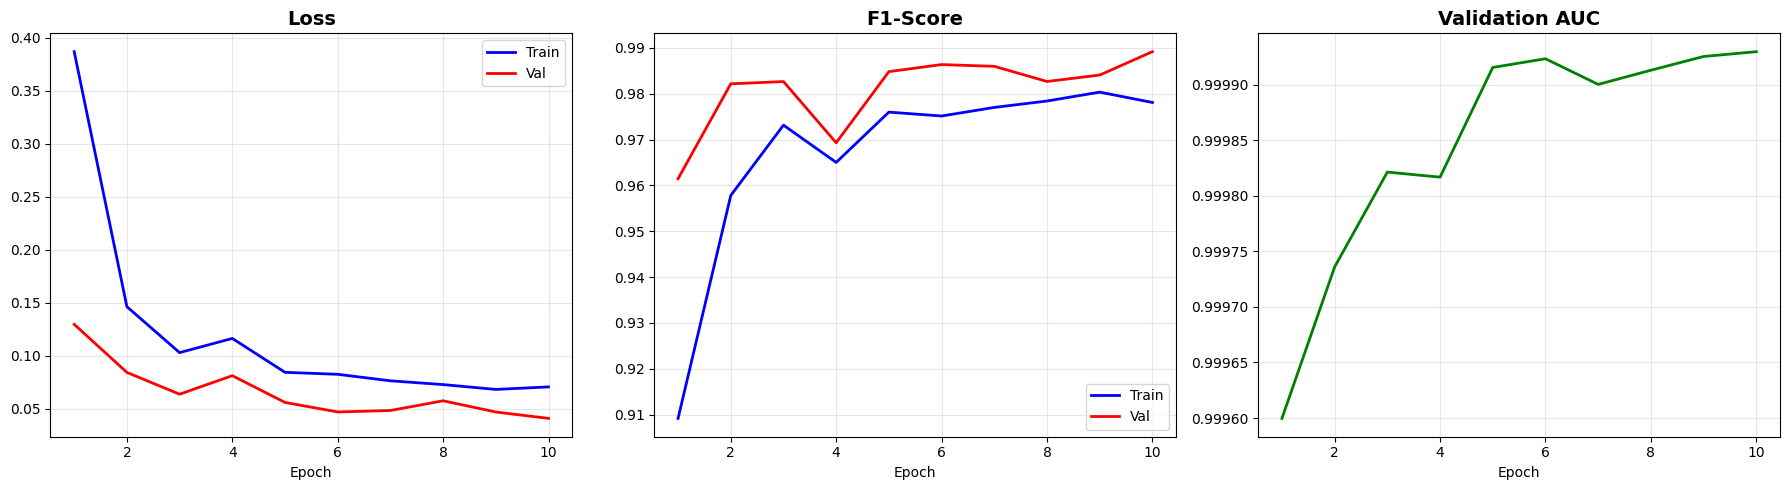

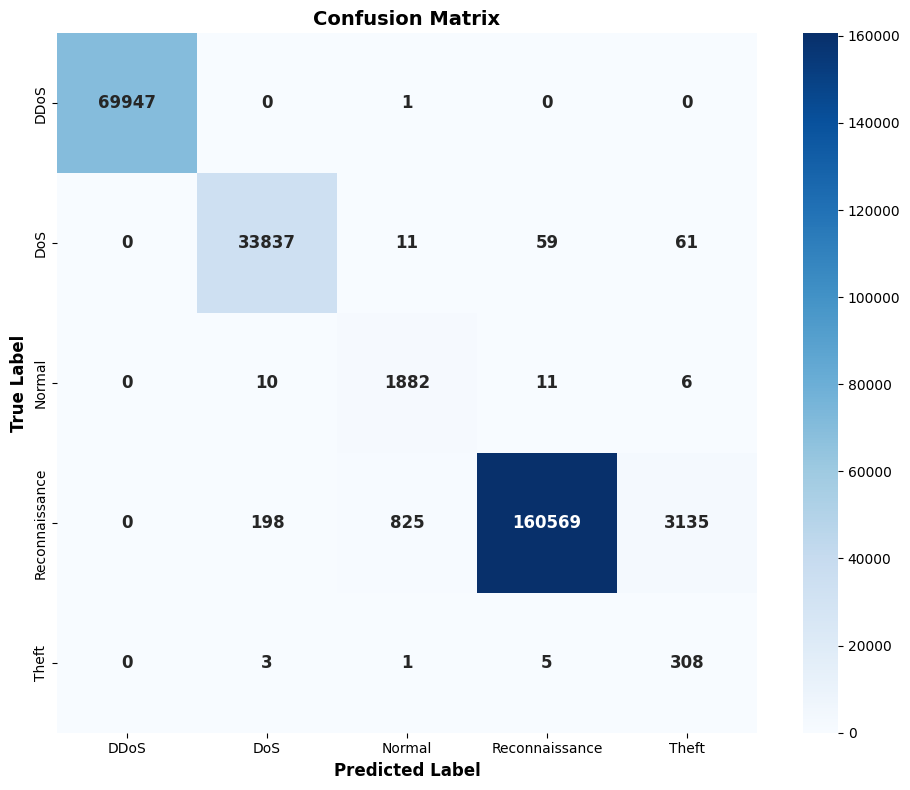

In [ ]:
model, trainer, results, preprocessor = train_model(combined_data, Config)